In [1]:
import flopy
import numpy as np
import matplotlib.pyplot as plt
import xmf6
from gypsum import vis

In [2]:
# Usamos LaTeX para los tectos de la figura.
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  
    "font.serif": ["Computer Modern Roman"],
})

In [3]:
# Cargamos el modelo de transporte
o_sim_t = flopy.mf6.MFSimulation.load(
    sim_ws="output_gwf_gwt_api_wma/gwt",
    verbosity_level=0,
)

# Obtenemos los objetos de cada modelo
o_gwt = o_sim_t.get_model("transport")

# Recuperamos las coordenadas del dominio
grid = o_gwt.modelgrid

# Recuperamos las coordenadas de los centros de las celdas de la malla
x = grid.xcellcenters[0] # centros de los volúmenes
print(x)

[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5]


In [4]:
c_gwt = vis.data_recovery("gypsum_eq_gwt.out")
c_dfc = vis.data_recovery("gypsum_eq_dfc.out")
c1, c2, an_c1, an_c2 = vis.data_recovery_excel("comparativa_02.xlsx")

In [5]:
# GWT error
#
# Calculamos el RMSE (https://en.wikipedia.org/wiki/Root_mean_square_deviation)
RMSE1_gwt = np.linalg.norm(an_c1 - c_gwt[0]) / np.sqrt(len(c_gwt[0]))
RMSE2_gwt = np.linalg.norm(an_c2 - c_gwt[1]) / np.sqrt(len(c_gwt[1]))
#
# Calculamos el MAPE (https://en.wikipedia.org/wiki/Mean_absolute_percentage_error)
MAPE1_gwt = np.mean(np.abs((an_c1 - c_gwt[0]) / an_c1)) * 100
MAPE2_gwt = np.mean(np.abs((an_c2 - c_gwt[1]) / an_c2)) * 100

xmf6.nice_print("GWT Error")
print(f"RMSE c1: {RMSE1_gwt:5.2e} \t RMSE c2: {RMSE2_gwt:5.2e}")
print(f"MAPE c1: {MAPE1_gwt:5.2f}% \t MAPE c2: {MAPE2_gwt:5.2f}")

print()
# DFC error
#
# Calculamos el RMSE (https://en.wikipedia.org/wiki/Root_mean_square_deviation)
RMSE1_dfc = np.linalg.norm(an_c1 - c_dfc[0]) / np.sqrt(len(c_dfc[0]))
RMSE2_dfc = np.linalg.norm(an_c2 - c_dfc[1]) / np.sqrt(len(c_dfc[1]))
#
# Calculamos el MAPE (https://en.wikipedia.org/wiki/Mean_absolute_percentage_error)
MAPE1_dfc = np.mean(np.abs((an_c1 - c_dfc[0]) / an_c1)) * 100
MAPE2_dfc = np.mean(np.abs((an_c2 - c_dfc[1]) / an_c2)) * 100

xmf6.nice_print("DFC Error")
print(f"RMSE c1: {RMSE1_dfc:5.2e} \t RMSE c2: {RMSE2_dfc:5.2e}")
print(f"MAPE c1: {MAPE1_dfc:5.2f}% \t MAPE c2: {MAPE2_dfc:5.2f}")


GWT Error
―――――――――

RMSE c1: 1.93e+00 	 RMSE c2: 4.33e-06
MAPE c1: 14.91% 	 MAPE c2: 19.75


DFC Error
―――――――――

RMSE c1: 1.48e+00 	 RMSE c2: 3.45e-06
MAPE c1: 14.97% 	 MAPE c2: 12.43


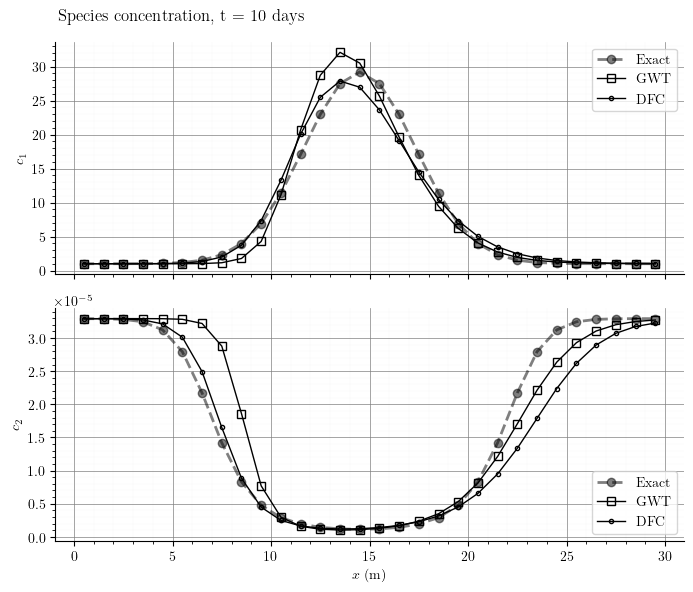

In [6]:
vis.plot(x, (an_c1, an_c2), 
        (c_gwt, c_dfc), ("s-", ".-"), ("GWT", "DFC"),
        savefig = True)